# Transformer Time Series Forecasting for Financial Data

This notebook trains a Hugging Face `TimeSeriesTransformerForPrediction` model to forecast the next 30 log-return steps for each ticker, then converts those forecasts back into price paths with confidence bands.

## What this notebook does
- Downloads and pools multi-ticker OHLCV data
- Builds technical indicators and log returns
- Encodes tickers as static categorical IDs
- Uses calendar-based time features from the datetime index
- Trains a probabilistic Transformer with AdamW on GPU when available
- Exports the model, per-ticker scaler objects, and ticker encoder

Set either `TICKERS` or `TICKER_CSV_PATH` in the config cell before running the notebook.

In [2]:
!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
scikit-learn==1.4.2 \
transformers==4.41.2 \
yfinance \
torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
hdbs

In [2]:
INDIA_BLUECHIP = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "KOTAKBANK.NS", "SBIN.NS", "AXISBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS",
    "LT.NS", "ASIANPAINT.NS", "BAJFINANCE.NS",
    "MARUTI.NS", "TITAN.NS",
    "SUNPHARMA.NS", "DRREDDY.NS", "DIVISLAB.NS",
    "ULTRACEMCO.NS", "JSWSTEEL.NS", "TATASTEEL.NS",
    "POWERGRID.NS", "NTPC.NS", "ONGC.NS"
]
INDIA_GROWTH = [
    "ADANIENT.NS", "ADANIGREEN.NS", "ADANIPORTS.NS",
    "ZOMATO.NS", "PAYTM.NS", "NYKAA.NS",
    "IRCTC.NS", "DMART.NS",
    "BAJAJFINSV.NS", "INDIGO.NS"
]
INDIA_INDICES = [
    "^NSEI",      # Nifty 50
    "^NSEBANK",   # Bank Nifty
    "^BSESN"      # Sensex
]
US_DIVERSIFIED = [
    "JPM", "GS", "BAC",
    "WMT", "PG", "KO",
    "DIS", "NKE",
    "XOM", "CVX"
]
US_TECH = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
    "META", "TSLA"
]

US_INDICES = [
    "^GSPC",   # S&P 500
    "^IXIC",   # Nasdaq
    "^DJI",    # Dow Jones
    "SPY", "QQQ"
]

In [4]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 10.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully unin

In [3]:
import json
import math
import os
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_ta as ta
import torch
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction

# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------------------------------------------------------
# Core forecast configuration
# -----------------------------------------------------------------------------
CONTEXT_LENGTH = 60
PREDICTION_LENGTH = 30
LAGS_SEQUENCE = list(range(1, 8))
HISTORY_LENGTH = CONTEXT_LENGTH + max(LAGS_SEQUENCE)
TIME_FEATURE_COLUMNS = ['day_of_week', 'month']
VAL_RATIO = 0.15
TEST_RATIO = 0.15
BATCH_SIZE = 16
NUM_EPOCHS = 8
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-2
PATIENCE = 3
MAX_GRAD_NORM = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -----------------------------------------------------------------------------
# Paths and ticker input
# -----------------------------------------------------------------------------
if Path('/content').exists() and os.access('/content', os.W_OK):
    PROJECT_DIR = Path('/content/finintel_ts_transformer')
else:
    PROJECT_DIR = Path.cwd() / 'finintel_ts_transformer'
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = PROJECT_DIR / 'pooled_dataset.pkl'
MODEL_DIR = PROJECT_DIR / 'model'
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Set one of these before running the data cell.
TICKERS = (
    INDIA_BLUECHIP +
    INDIA_GROWTH +
    INDIA_INDICES +
    US_TECH +
    US_DIVERSIFIED +
    US_INDICES
)
TICKER_CSV_PATH = ''  # Optional CSV with a Ticker column

print(f'Device: {DEVICE}')
print(f'Project dir: {PROJECT_DIR}')

Device: cuda
Project dir: /content/finintel_ts_transformer


In [4]:
def _merge_feature_block(base_df: pd.DataFrame, feature_block):
    if feature_block is None:
        return base_df
    if isinstance(feature_block, pd.Series):
        feature_block = feature_block.to_frame()
    return base_df.join(feature_block)

def create_pooled_dataset(tickers, period='5y'):
    all_data = []

    for ticker in tickers:
        print(f'Processing: {ticker}')
        try:
            df = yf.download(ticker, period=period, auto_adjust=False, progress=False)
            if df.empty:
                print(f'  skipped: no data returned for {ticker}')
                continue

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df.index = pd.to_datetime(df.index)
            df = df.sort_index()

            for length in [5, 10, 14, 15]:
                df[f'rsi_{length}'] = ta.rsi(df['Close'], length=length)
            df['roc_10'] = ta.roc(df['Close'], length=10)
            df['mom_10'] = ta.mom(df['Close'], length=10)

            df = _merge_feature_block(df, ta.stochrsi(df['Close']))
            df['cci_20'] = ta.cci(df['High'], df['Low'], df['Close'], length=20)
            df['wr_14'] = ta.willr(df['High'], df['Low'], df['Close'], length=14)
            df = _merge_feature_block(df, ta.kst(df['Close']))

            macd_df = ta.macd(df['Close'])
            df = _merge_feature_block(df, macd_df)

            for length in [5, 10, 20]:
                df[f'sma_{length}'] = ta.sma(df['Close'], length=length)
                df[f'ema_{length}'] = ta.ema(df['Close'], length=length)
            df['vwma_20'] = ta.vwma(df['Close'], df['Volume'], length=20)

            df = _merge_feature_block(df, ta.bbands(df['Close'], length=20))
            df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
            df = _merge_feature_block(df, ta.kc(df['High'], df['Low'], df['Close'], length=20))

            df['obv'] = ta.obv(df['Close'], df['Volume'])
            df['ad'] = ta.ad(df['High'], df['Low'], df['Close'], df['Volume'])
            df['efi'] = ta.efi(df['Close'], df['Volume'])
            df = _merge_feature_block(df, ta.nvi(df['Close'], df['Volume']))
            df = _merge_feature_block(df, ta.pvi(df['Close'], df['Volume']))

            df['Log_Ret'] = np.log(df['Close']).diff()
            df['Ticker'] = ticker

            df = df.dropna().copy()
            all_data.append(df)
        except Exception as exc:
            print(f'  error fetching {ticker}: {exc}')

    if not all_data:
        return pd.DataFrame()

    master_df = pd.concat(all_data, axis=0).sort_index()
    return master_df

def load_ticker_universe():
    if TICKERS is not None:
        tickers = [str(t).strip().upper() for t in TICKERS if str(t).strip()]
        if tickers:
            return sorted(dict.fromkeys(tickers))

    if TICKER_CSV_PATH and Path(TICKER_CSV_PATH).exists():
        ticker_df = pd.read_csv(TICKER_CSV_PATH)
        if 'Ticker' not in ticker_df.columns:
            raise ValueError('TICKER_CSV_PATH must point to a CSV with a Ticker column.')
        tickers = ticker_df['Ticker'].astype(str).str.strip().str.upper().tolist()
        tickers = [ticker for ticker in tickers if ticker]
        if tickers:
            return sorted(dict.fromkeys(tickers))

    raise ValueError('Set TICKERS in the config cell or provide TICKER_CSV_PATH before continuing.')

def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame['day_of_week'] = frame.index.dayofweek.astype(np.float32) / 6.0
    frame['month'] = (frame.index.month.astype(np.float32) - 1.0) / 11.0
    return frame

def fit_ticker_scaler(frame: pd.DataFrame, train_end: int) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(frame.iloc[:train_end][['Log_Ret']].values)
    return scaler

def build_window_samples(frame: pd.DataFrame, ticker_name: str, ticker_id: int, scaler: StandardScaler, train_end: int, val_end: int):
    frame = frame.copy()
    frame['Log_Ret_Scaled'] = scaler.transform(frame[['Log_Ret']].values).astype(np.float32)

    scaled_values = frame['Log_Ret_Scaled'].to_numpy(dtype=np.float32)
    close_values = frame['Close'].to_numpy(dtype=np.float32)
    time_features = frame[TIME_FEATURE_COLUMNS].to_numpy(dtype=np.float32)

    sample_buckets = {'train': [], 'val': [], 'test': []}
    last_forecast_start = len(frame) - PREDICTION_LENGTH + 1

    for forecast_start in range(HISTORY_LENGTH, last_forecast_start):
        past_start = forecast_start - HISTORY_LENGTH
        past_end = forecast_start
        future_end = forecast_start + PREDICTION_LENGTH

        sample = {
            'past_values': scaled_values[past_start:past_end].astype(np.float32),
            'future_values': scaled_values[forecast_start:future_end].astype(np.float32),
            'past_time_features': time_features[past_start:past_end].astype(np.float32),
            'future_time_features': time_features[forecast_start:future_end].astype(np.float32),
            'past_observed_mask': np.ones(HISTORY_LENGTH, dtype=np.float32),
            'future_observed_mask': np.ones(PREDICTION_LENGTH, dtype=np.float32),
            'static_categorical_features': np.array([ticker_id], dtype=np.int64),
            'history_close': close_values[past_start:past_end].astype(np.float32),
            'ticker_name': ticker_name,
            'ticker_id': ticker_id,
            'forecast_start': frame.index[forecast_start],
        }

        if forecast_start < train_end:
            sample_buckets['train'].append(sample)
        elif forecast_start < val_end:
            sample_buckets['val'].append(sample)
        else:
            sample_buckets['test'].append(sample)

    return sample_buckets

class FinancialForecastDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        return {
            'past_values': torch.tensor(sample['past_values'], dtype=torch.float32),
            'future_values': torch.tensor(sample['future_values'], dtype=torch.float32),
            'past_time_features': torch.tensor(sample['past_time_features'], dtype=torch.float32),
            'future_time_features': torch.tensor(sample['future_time_features'], dtype=torch.float32),
            'past_observed_mask': torch.tensor(sample['past_observed_mask'], dtype=torch.float32),
            'future_observed_mask': torch.tensor(sample['future_observed_mask'], dtype=torch.float32),
            'static_categorical_features': torch.tensor(sample['static_categorical_features'], dtype=torch.long),
            'history_close': torch.tensor(sample['history_close'], dtype=torch.float32),
            'ticker_name': sample['ticker_name'],
            'ticker_id': sample['ticker_id'],
        }

In [5]:
# -----------------------------------------------------------------------------
# Load or build the pooled dataset
# -----------------------------------------------------------------------------
tickers = load_ticker_universe()
print(f'Ticker universe ({len(tickers)}): {tickers}')

if CACHE_PATH.exists():
    pooled_df = pd.read_pickle(CACHE_PATH)
    print(f'Loaded cached pooled dataset with shape: {pooled_df.shape}')
else:
    pooled_df = create_pooled_dataset(tickers, period='5y')
    if pooled_df.empty:
        raise ValueError('No data was returned. Check your tickers or network access.')
    pooled_df.to_pickle(CACHE_PATH)
    print(f'Saved pooled dataset cache to: {CACHE_PATH}')

if 'Ticker' not in pooled_df.columns:
    raise ValueError('The pooled dataset must include a Ticker column.')

pooled_df = pooled_df.sort_index().copy()
pooled_df = pooled_df[pooled_df['Ticker'].isin(tickers)].copy()
pooled_df = add_calendar_features(pooled_df)
pooled_df = pooled_df.dropna(subset=['Close', 'Log_Ret']).copy()
print(f'Pooled dataset shape after cleanup: {pooled_df.shape}')

ticker_to_id = {ticker: idx for idx, ticker in enumerate(sorted(tickers))}
id_to_ticker = {idx: ticker for ticker, idx in ticker_to_id.items()}
num_tickers = len(ticker_to_id)

train_samples = []
val_samples = []
test_samples = []
ticker_scalers = {}
ticker_frame_cache = {}

for ticker in sorted(tickers):
    ticker_frame = pooled_df[pooled_df['Ticker'] == ticker].sort_index().copy()
    ticker_frame = add_calendar_features(ticker_frame)
    ticker_frame = ticker_frame.dropna(subset=['Close', 'Log_Ret']).copy()

    if len(ticker_frame) < HISTORY_LENGTH + PREDICTION_LENGTH + 5:
        print(f'Skipping {ticker}: not enough rows after feature engineering ({len(ticker_frame)} rows)')
        continue

    train_end = int(len(ticker_frame) * (1 - VAL_RATIO - TEST_RATIO))
    val_end = int(len(ticker_frame) * (1 - TEST_RATIO))
    train_end = max(train_end, HISTORY_LENGTH + PREDICTION_LENGTH)
    val_end = max(val_end, train_end + PREDICTION_LENGTH)

    scaler = fit_ticker_scaler(ticker_frame, train_end=train_end)
    ticker_scalers[ticker] = scaler
    ticker_frame_cache[ticker] = ticker_frame

    split_samples = build_window_samples(
        frame=ticker_frame,
        ticker_name=ticker,
        ticker_id=ticker_to_id[ticker],
        scaler=scaler,
        train_end=train_end,
        val_end=val_end,
    )
    train_samples.extend(split_samples['train'])
    val_samples.extend(split_samples['val'])
    test_samples.extend(split_samples['test'])

print(f'Train samples: {len(train_samples)}')
print(f'Val samples:   {len(val_samples)}')
print(f'Test samples:  {len(test_samples)}')

if not train_samples or not val_samples or not test_samples:
    raise ValueError('One of the dataset splits is empty. Add more tickers or use a longer period.')

train_dataset = FinancialForecastDataset(train_samples)
val_dataset = FinancialForecastDataset(val_samples)
test_dataset = FinancialForecastDataset(test_samples)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

MODEL_INPUT_KEYS = {
    'past_values',
    'future_values',
    'past_time_features',
    'future_time_features',
    'past_observed_mask',
    'static_categorical_features',
}

config = TimeSeriesTransformerConfig(
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    input_size=1,
    num_time_features=len(TIME_FEATURE_COLUMNS),
    num_static_categorical_features=1,
    cardinality=[num_tickers],
    embedding_dimension=[min(16, max(4, num_tickers // 2))],
    lags_sequence=LAGS_SEQUENCE,
)

model = TimeSeriesTransformerForPrediction(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
amp_enabled = torch.cuda.is_available()
grad_scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

def to_device(batch):
    return {key: value.to(DEVICE) for key, value in batch.items() if key in MODEL_INPUT_KEYS}

def run_validation(current_model, data_loader):
    current_model.eval()
    losses = []
    with torch.no_grad():
        for batch in data_loader:
            model_batch = to_device(batch)
            outputs = current_model(**model_batch)
            losses.append(outputs.loss.item())
    return float(np.mean(losses)) if losses else float('nan')

print('Model initialized successfully.')

Ticker universe (60): ['AAPL', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS', 'AMZN', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAC', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'CVX', 'DIS', 'DIVISLAB.NS', 'DMART.NS', 'DRREDDY.NS', 'GOOGL', 'GS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDIGO.NS', 'INFY.NS', 'IRCTC.NS', 'ITC.NS', 'JPM', 'JSWSTEEL.NS', 'KO', 'KOTAKBANK.NS', 'LT.NS', 'MARUTI.NS', 'META', 'MSFT', 'NESTLEIND.NS', 'NKE', 'NTPC.NS', 'NVDA', 'NYKAA.NS', 'ONGC.NS', 'PAYTM.NS', 'PG', 'POWERGRID.NS', 'QQQ', 'RELIANCE.NS', 'SBIN.NS', 'SPY', 'SUNPHARMA.NS', 'TATASTEEL.NS', 'TCS.NS', 'TITAN.NS', 'TSLA', 'ULTRACEMCO.NS', 'WMT', 'XOM', 'ZOMATO.NS', '^BSESN', '^DJI', '^GSPC', '^IXIC', '^NSEBANK', '^NSEI']
Processing: AAPL
Processing: ADANIENT.NS
Processing: ADANIGREEN.NS
Processing: ADANIPORTS.NS
Processing: AMZN
Processing: ASIANPAINT.NS
Processing: AXISBANK.NS
Processing: BAC
Processing: BAJAJFINSV.NS
Processing: BAJFINANCE.NS
Processing: CVX
Processing: DIS
Processing: DIVISLAB.NS
Process

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZOMATO.NS"}}}
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/quote.py:700: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ZOMATO.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


  skipped: no data returned for ZOMATO.NS
Processing: ^BSESN
Processing: ^DJI
Processing: ^GSPC
Processing: ^IXIC
Processing: ^NSEBANK
Processing: ^NSEI
Saved pooled dataset cache to: /content/finintel_ts_transformer/pooled_dataset.pkl
Pooled dataset shape after cleanup: (58132, 47)
Skipping ZOMATO.NS: not enough rows after feature engineering (0 rows)
Train samples: 36725
Val samples:   8698
Test samples:  7045
Model initialized successfully.


/tmp/ipykernel_1908/487750997.py:122: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


In [6]:
# -----------------------------------------------------------------------------
# Training loop with validation and early stopping
# -----------------------------------------------------------------------------
best_val_loss = float('inf')
best_epoch = -1
epochs_without_improvement = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False)
    for batch in progress_bar:
        model_batch = to_device(batch)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            outputs = model(**model_batch)
            loss = outputs.loss

        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        grad_scaler.step(optimizer)
        grad_scaler.update()

        loss_value = loss.item()
        train_losses.append(loss_value)
        progress_bar.set_postfix({'loss': f'{loss_value:.4f}'})

    train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
    val_loss = run_validation(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(MODEL_DIR)
        print(f'  saved new best model to {MODEL_DIR}')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered.')
            break

history_path = ARTIFACTS_DIR / 'training_history.json'
with open(history_path, 'w', encoding='utf-8') as handle:
    json.dump(history, handle, indent=2)

print(f'Best epoch: {best_epoch} | best_val_loss={best_val_loss:.6f}')
print(f'Training history saved to: {history_path}')

Epoch 1/8:   0%|          | 0/2296 [00:00<?, ?it/s]

/tmp/ipykernel_1908/1686007032.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Epoch 01 | train_loss=1.289284 | val_loss=1.261532
  saved new best model to /content/finintel_ts_transformer/model


Epoch 2/8:   0%|          | 0/2296 [00:00<?, ?it/s]

/tmp/ipykernel_1908/1686007032.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


...

Epoch 03 | train_loss=1.274952 | val_loss=1.259156


Epoch 4/8:   0%|          | 0/2296 [00:00<?, ?it/s]

Epoch 04 | train_loss=1.270586 | val_loss=1.261495


Epoch 5/8:   0%|          | 0/2296 [00:00<?, ?it/s]

Epoch 05 | train_loss=1.267513 | val_loss=1.265883
Early stopping triggered.
Best epoch: 2 | best_val_loss=1.258352
Training history saved to: /content/finintel_ts_transformer/artifacts/training_history.json


Test loss: 1.292493
Test MAE (log returns): 0.011315
Test RMSE (log returns): 0.016289
{'history_length': 67, 'prediction_length': 30, 'ticker': 'AAPL'}


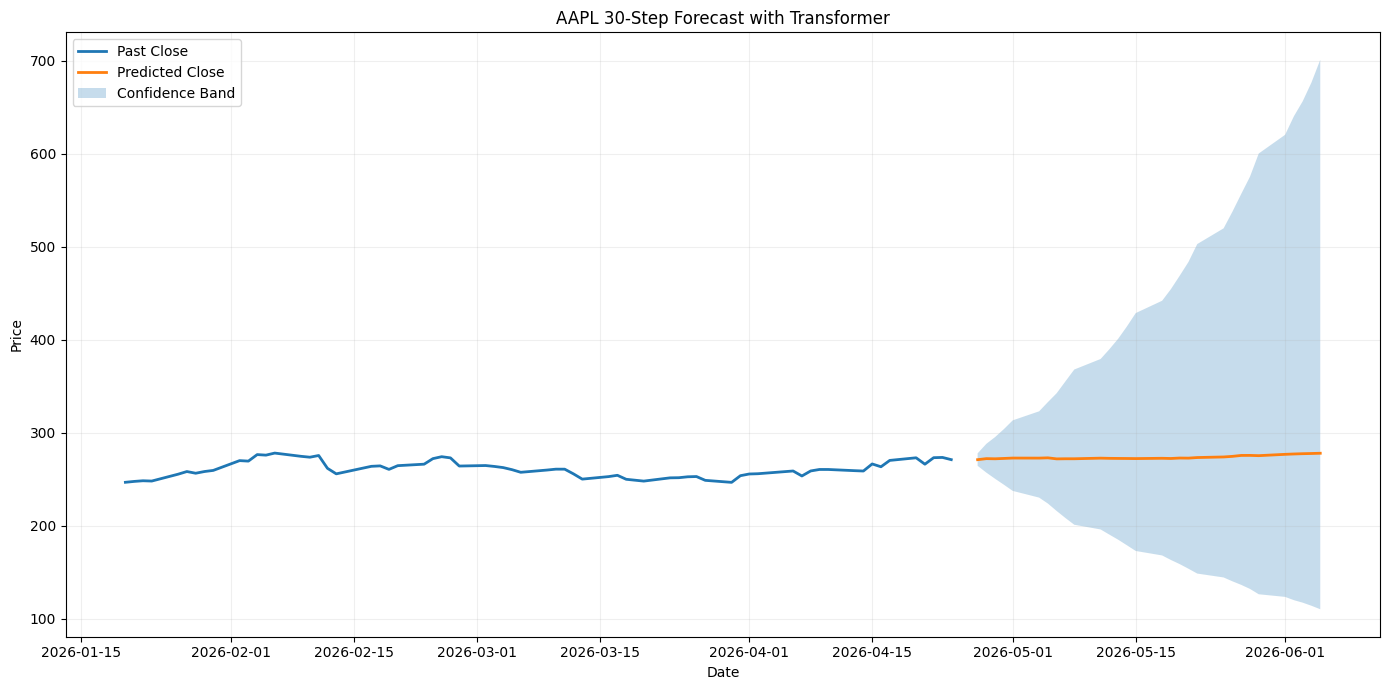

In [7]:
# -----------------------------------------------------------------------------
# Evaluation, probabilistic confidence intervals, and price reconstruction
# -----------------------------------------------------------------------------
best_model = TimeSeriesTransformerForPrediction.from_pretrained(MODEL_DIR).to(DEVICE)
best_model.eval()

def get_forecast_distribution(current_model, outputs):
    if hasattr(current_model, 'output_distribution'):
        return current_model.output_distribution(outputs.params, loc=outputs.loc, scale=outputs.scale)
    if hasattr(current_model, 'distribution_output'):
        return current_model.distribution_output.distribution(outputs.params, loc=outputs.loc, scale=outputs.scale)
    raise AttributeError('The installed transformers version does not expose a forecast distribution helper.')

def inverse_scale_returns(ticker_name, scaled_returns):
    scaler = ticker_scalers[ticker_name]
    return scaler.inverse_transform(np.asarray(scaled_returns).reshape(-1, 1)).reshape(-1)

def returns_to_price_path(last_price, log_return_path):
    log_return_path = np.asarray(log_return_path, dtype=np.float64)
    return last_price * np.exp(np.cumsum(log_return_path))

def sample_forecast_scaled_paths(current_model, model_inputs):
    with torch.no_grad():
        generated = current_model.generate(
            past_values=model_inputs['past_values'],
            past_time_features=model_inputs['past_time_features'],
            future_time_features=model_inputs['future_time_features'],
            past_observed_mask=model_inputs['past_observed_mask'],
            static_categorical_features=model_inputs['static_categorical_features'],
        )

    sampled_paths = np.asarray(generated.sequences.detach().cpu().numpy()).squeeze()
    if sampled_paths.ndim == 1:
        sampled_paths = sampled_paths[np.newaxis, :]
    if sampled_paths.ndim == 3 and sampled_paths.shape[-1] == 1:
        sampled_paths = sampled_paths[..., 0]
    return sampled_paths

def predict_from_ticker_frame(current_model, ticker_frame: pd.DataFrame, ticker_name: str):
    ticker_frame = ticker_frame.sort_index().copy()
    ticker_frame = add_calendar_features(ticker_frame)
    scaler = ticker_scalers[ticker_name]
    ticker_frame['Log_Ret_Scaled'] = scaler.transform(ticker_frame[['Log_Ret']].values).astype(np.float32)

    if len(ticker_frame) < HISTORY_LENGTH:
        raise ValueError(f'{ticker_name} does not have enough rows for inference.')

    history_frame = ticker_frame.iloc[-HISTORY_LENGTH:].copy()
    last_price = float(history_frame['Close'].iloc[-1])

    future_dates = pd.bdate_range(start=history_frame.index[-1] + pd.offsets.BDay(1), periods=PREDICTION_LENGTH)
    future_time_features = np.column_stack([
        future_dates.dayofweek.astype(np.float32) / 6.0,
        (future_dates.month.astype(np.float32) - 1.0) / 11.0,
    ])

    model_inputs = {
        'past_values': torch.tensor(history_frame['Log_Ret_Scaled'].to_numpy(dtype=np.float32), dtype=torch.float32, device=DEVICE).unsqueeze(0),
        'past_time_features': torch.tensor(history_frame[TIME_FEATURE_COLUMNS].to_numpy(dtype=np.float32), dtype=torch.float32, device=DEVICE).unsqueeze(0),
        'future_time_features': torch.tensor(future_time_features, dtype=torch.float32, device=DEVICE).unsqueeze(0),
        'past_observed_mask': torch.ones((1, HISTORY_LENGTH), dtype=torch.float32, device=DEVICE),
        'static_categorical_features': torch.tensor([[ticker_to_id[ticker_name]]], dtype=torch.long, device=DEVICE),
    }

    sampled_paths = sample_forecast_scaled_paths(current_model, model_inputs)
    mean_scaled = sampled_paths.mean(axis=0)
    std_scaled = sampled_paths.std(axis=0)

    mean_returns = inverse_scale_returns(ticker_name, mean_scaled)
    std_returns = std_scaled * ticker_scalers[ticker_name].scale_[0]
    lower_returns = mean_returns - 1.96 * std_returns
    upper_returns = mean_returns + 1.96 * std_returns

    prediction_prices = returns_to_price_path(last_price, mean_returns)
    lower_prices = returns_to_price_path(last_price, lower_returns)
    upper_prices = returns_to_price_path(last_price, upper_returns)

    return {
        'history': history_frame['Close'].to_numpy(dtype=np.float32),
        'future_dates': future_dates,
        'prediction': prediction_prices,
        'upper': upper_prices,
        'lower': lower_prices,
        'mean_log_returns': mean_returns,
        'std_log_returns': std_returns,
    }

# Evaluate on the test split in log-return space.
all_test_targets = []
all_test_predictions = []
test_losses = []

with torch.no_grad():
    for batch in test_loader:
        ticker_names = batch['ticker_name']
        model_batch = to_device(batch)
        outputs = best_model(**model_batch)
        distribution = get_forecast_distribution(best_model, outputs)

        mean_scaled = np.asarray(distribution.mean.detach().cpu().numpy())
        if mean_scaled.ndim == 1:
            mean_scaled = mean_scaled[np.newaxis, :]
        if mean_scaled.ndim == 3 and mean_scaled.shape[-1] == 1:
            mean_scaled = mean_scaled[..., 0]

        target_scaled = batch['future_values'].numpy()

        for i, ticker_name in enumerate(ticker_names):
            pred_returns = inverse_scale_returns(ticker_name, mean_scaled[i])
            true_returns = inverse_scale_returns(ticker_name, target_scaled[i])
            all_test_predictions.append(pred_returns)
            all_test_targets.append(true_returns)

        test_losses.append(outputs.loss.item())

test_predictions = np.concatenate(all_test_predictions, axis=0)
test_targets = np.concatenate(all_test_targets, axis=0)
test_mae = mean_absolute_error(test_targets, test_predictions)
test_rmse = math.sqrt(mean_squared_error(test_targets, test_predictions))
test_loss = float(np.mean(test_losses)) if test_losses else float('nan')

print(f'Test loss: {test_loss:.6f}')
print(f'Test MAE (log returns): {test_mae:.6f}')
print(f'Test RMSE (log returns): {test_rmse:.6f}')

# Example inference on the first ticker in the trained universe.
example_ticker = sorted(ticker_scalers.keys())[0]
example_frame = ticker_frame_cache[example_ticker]
forecast_result = predict_from_ticker_frame(best_model, example_frame, example_ticker)

print({
    'history_length': len(forecast_result['history']),
    'prediction_length': len(forecast_result['prediction']),
    'ticker': example_ticker,
})

# Visualization
history_prices = forecast_result['history']
prediction_prices = forecast_result['prediction']
lower_prices = forecast_result['lower']
upper_prices = forecast_result['upper']
future_dates = forecast_result['future_dates']
history_dates = example_frame.iloc[-HISTORY_LENGTH:].index

plt.figure(figsize=(14, 7))
plt.plot(history_dates, history_prices, label='Past Close', linewidth=2)
plt.plot(future_dates, prediction_prices, label='Predicted Close', linewidth=2)
plt.fill_between(future_dates, lower_prices, upper_prices, alpha=0.25, label='Confidence Band')
plt.title(f'{example_ticker} 30-Step Forecast with Transformer')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [8]:
# -----------------------------------------------------------------------------
# Export model, scalers, and ticker encoder
# -----------------------------------------------------------------------------
EXPORT_DIR = PROJECT_DIR / 'exported_assets'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(EXPORT_DIR / 'model')

with open(EXPORT_DIR / 'ticker_scalers.pkl', 'wb') as handle:
    pickle.dump(ticker_scalers, handle)

with open(EXPORT_DIR / 'ticker_encoder.json', 'w', encoding='utf-8') as handle:
    json.dump(ticker_to_id, handle, indent=2)

metadata = {
    'tickers': sorted(ticker_to_id.keys()),
    'ticker_to_id': ticker_to_id,
    'context_length': CONTEXT_LENGTH,
    'prediction_length': PREDICTION_LENGTH,
    'history_length': HISTORY_LENGTH,
    'time_feature_columns': TIME_FEATURE_COLUMNS,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'test_loss': test_loss,
    'test_mae_log_returns': test_mae,
    'test_rmse_log_returns': test_rmse,
}

with open(EXPORT_DIR / 'metadata.json', 'w', encoding='utf-8') as handle:
    json.dump(metadata, handle, indent=2, default=str)

print(f"Model saved to: {EXPORT_DIR / 'model'}")
print(f"Scalers saved to: {EXPORT_DIR / 'ticker_scalers.pkl'}")
print(f"Ticker encoder saved to: {EXPORT_DIR / 'ticker_encoder.json'}")
print(f"Metadata saved to: {EXPORT_DIR / 'metadata.json'}")

Model saved to: /content/finintel_ts_transformer/exported_assets/model
Scalers saved to: /content/finintel_ts_transformer/exported_assets/ticker_scalers.pkl
Ticker encoder saved to: /content/finintel_ts_transformer/exported_assets/ticker_encoder.json
Metadata saved to: /content/finintel_ts_transformer/exported_assets/metadata.json


In [9]:
import shutil

shutil.make_archive(
    base_name="/content/exported_assets",
    format="zip",
    root_dir=EXPORT_DIR
)

'/content/exported_assets.zip'

In [10]:
from google.colab import files

files.download("/content/exported_assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>